In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats 
from scipy.stats import shapiro,levene
from scipy.stats import zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score

In [51]:
# pip install xgboost

In [52]:
df=pd.read_csv("Hotel Reservations.csv")
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [53]:
df.shape

(36275, 19)

In [54]:
df.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [56]:
# There is no null values in the data

## Bi-Variate Analysis

In [58]:
df['no_of_adults']=df['no_of_adults'].astype('object')

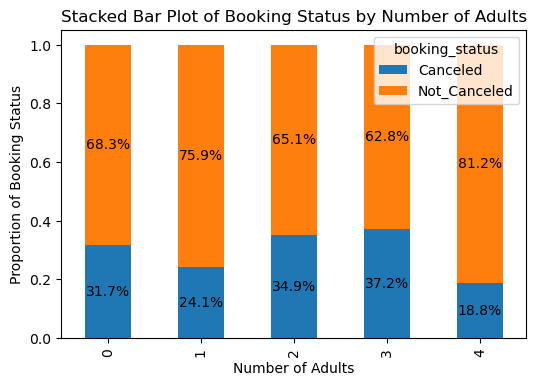

In [59]:
cross_tab_1 = pd.crosstab(df['no_of_adults'], df['booking_status'], normalize='index')
ax = cross_tab_1.plot(kind='bar', stacked=True, figsize=(6, 4))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('Number of Adults')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by Number of Adults')
plt.show()

In [60]:
# As the number of adults increases, the likelihood of cancellations decreases.

In [61]:
df['no_of_children']=df['no_of_children'].astype('object')

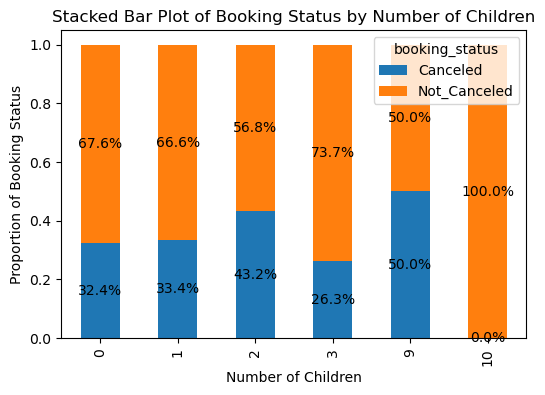

In [62]:
cross_tab_2 = pd.crosstab(df['no_of_children'], df['booking_status'], normalize='index')
ax = cross_tab_2.plot(kind='bar', stacked=True, figsize=(6, 4))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('Number of Children')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by Number of Children')
plt.show()

In [63]:
# As no.of children is high , likelihood of cancellation decreases.

In [64]:
df['no_of_weekend_nights']=df['no_of_weekend_nights'].astype('object')

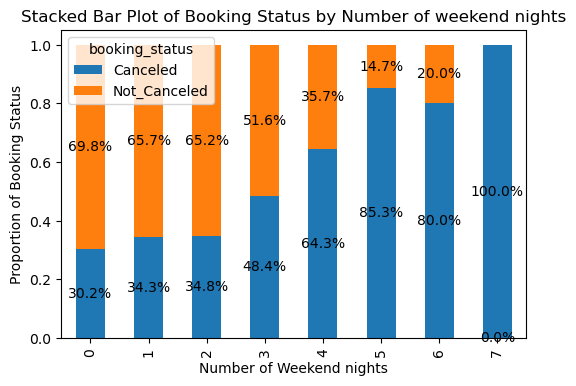

In [65]:
cross_tab_3 = pd.crosstab(df['no_of_weekend_nights'], df['booking_status'], normalize='index')
ax = cross_tab_3.plot(kind='bar', stacked=True, figsize=(6, 4))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('Number of Weekend nights')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by Number of weekend nights')
plt.show()

In [66]:
# As the number of weekend nights stayed increases, the likelihood of cancellations also increases.

In [67]:
df['no_of_week_nights']=df['no_of_week_nights'].astype('object')

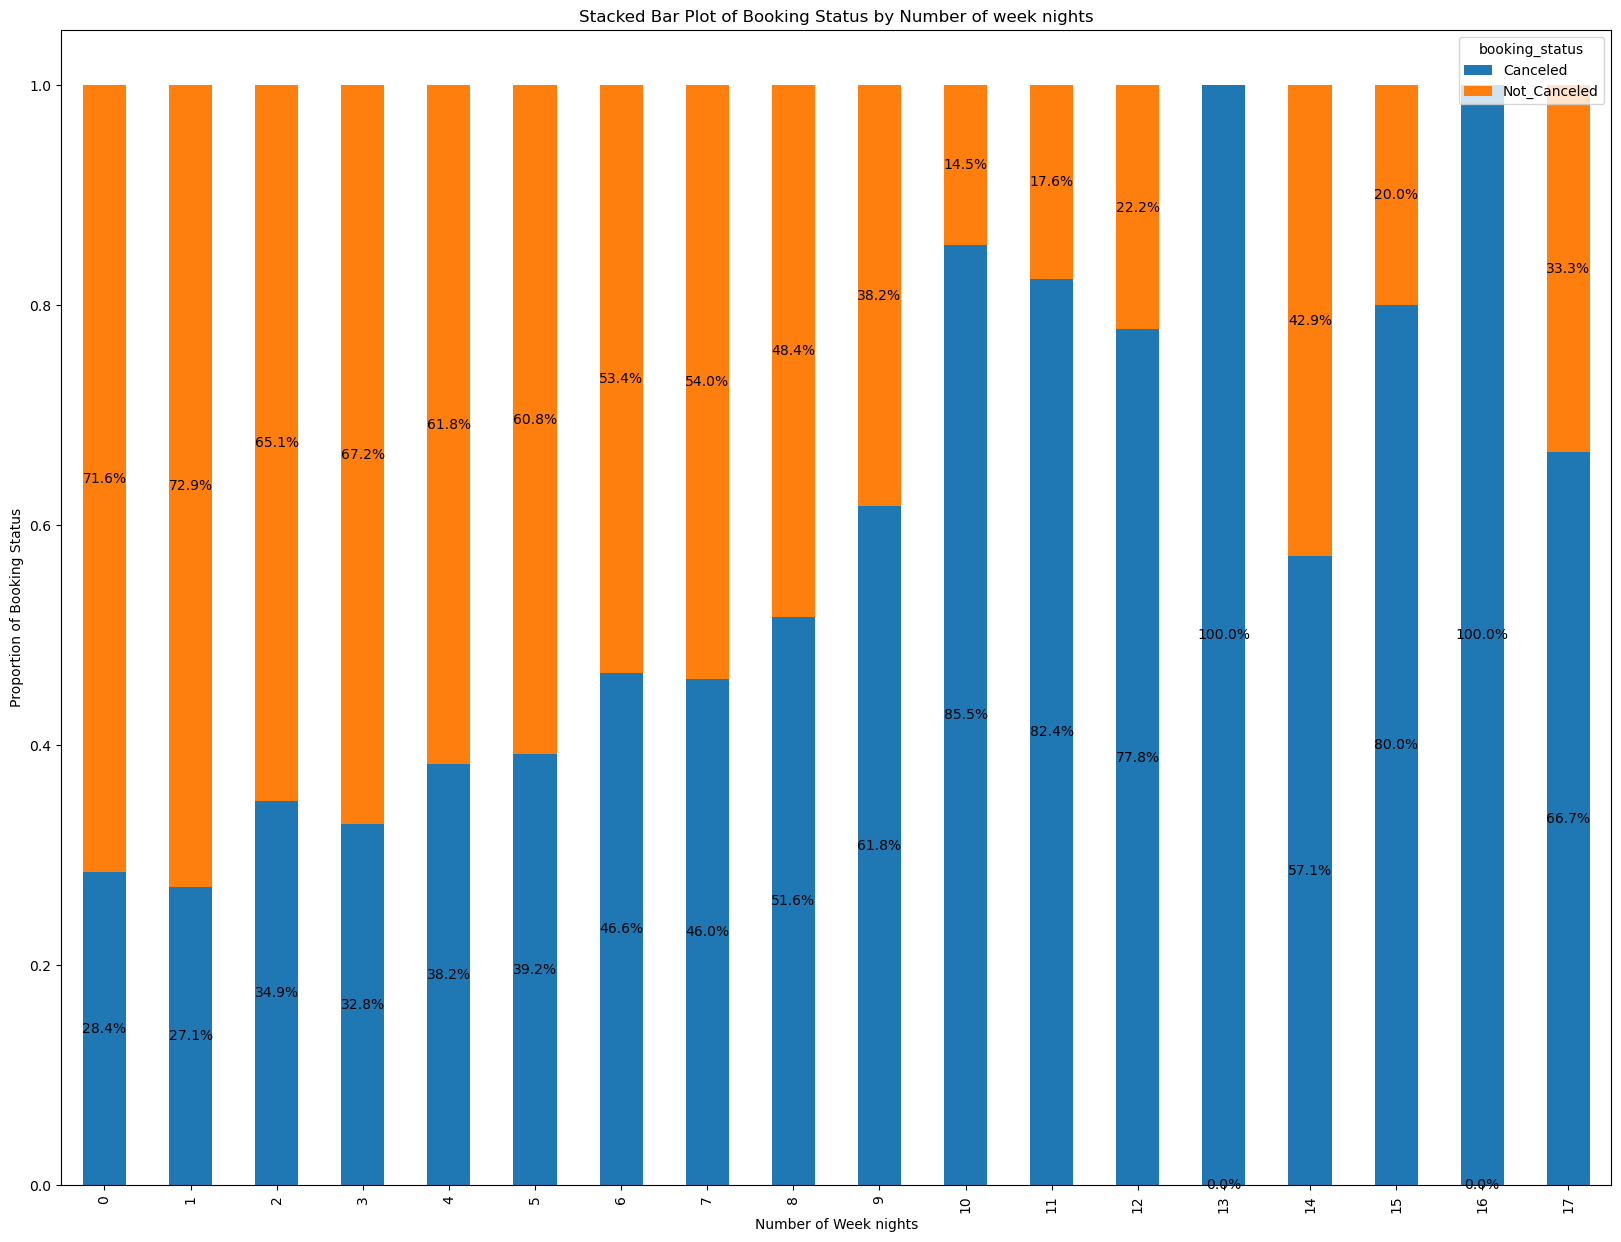

In [68]:
cross_tab_4 = pd.crosstab(df['no_of_week_nights'], df['booking_status'], normalize='index')
ax = cross_tab_4.plot(kind='bar', stacked=True, figsize=(20, 15))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('Number of Week nights')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by Number of week nights')
plt.show()

In [69]:
# According to the data, if the stay on weeknights is 5 nights or fewer, the likelihood of cancellation is lower.

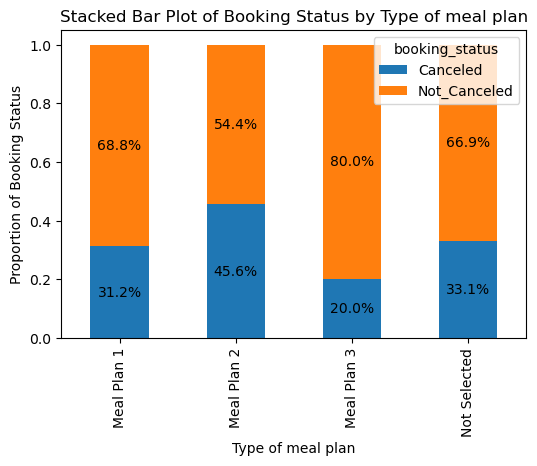

In [70]:
cross_tab_5 = pd.crosstab(df['type_of_meal_plan'], df['booking_status'], normalize='index')
ax = cross_tab_5.plot(kind='bar', stacked=True, figsize=(6, 4))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('Type of meal plan')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by Type of meal plan')
plt.show()

In [71]:
# The majority of people in the data choose meal plan 3.

In [72]:
df['required_car_parking_space']=df['required_car_parking_space'].astype('object')

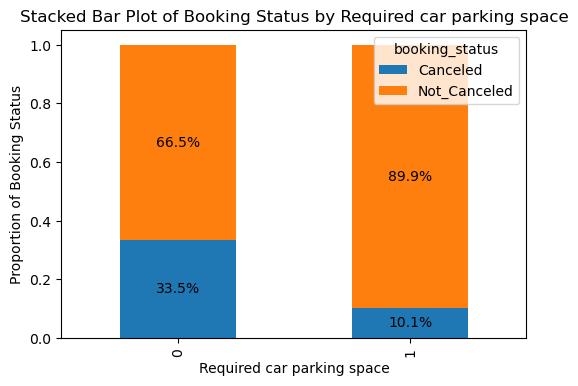

In [73]:
cross_tab_6 = pd.crosstab(df['required_car_parking_space'], df['booking_status'], normalize='index')
ax = cross_tab_6.plot(kind='bar', stacked=True, figsize=(6, 4))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('Required car parking space')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by Required car parking space')
plt.show()

In [74]:
# Most people booking hotels require a car parking space.

In [75]:
df['room_type_reserved']=df['room_type_reserved'].astype('object')

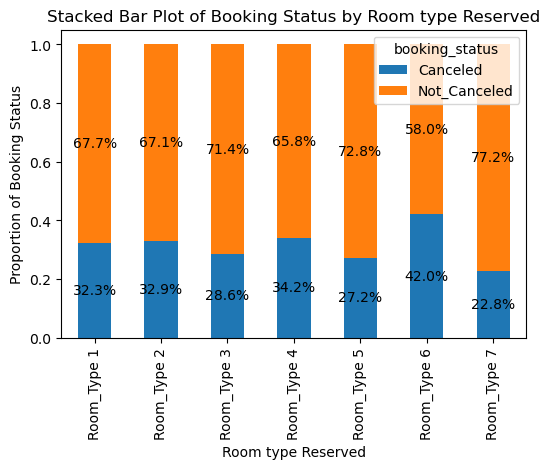

In [76]:
cross_tab_7 = pd.crosstab(df['room_type_reserved'], df['booking_status'], normalize='index')
ax = cross_tab_7.plot(kind='bar', stacked=True, figsize=(6, 4))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('Room type Reserved')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by Room type Reserved')
plt.show()

In [77]:
# According to the data, most bookings for Room Type 7 are not canceled.
# Highest cancellated happened on room type 6

In [78]:
df['arrival_year']=df['arrival_year'].astype('object')

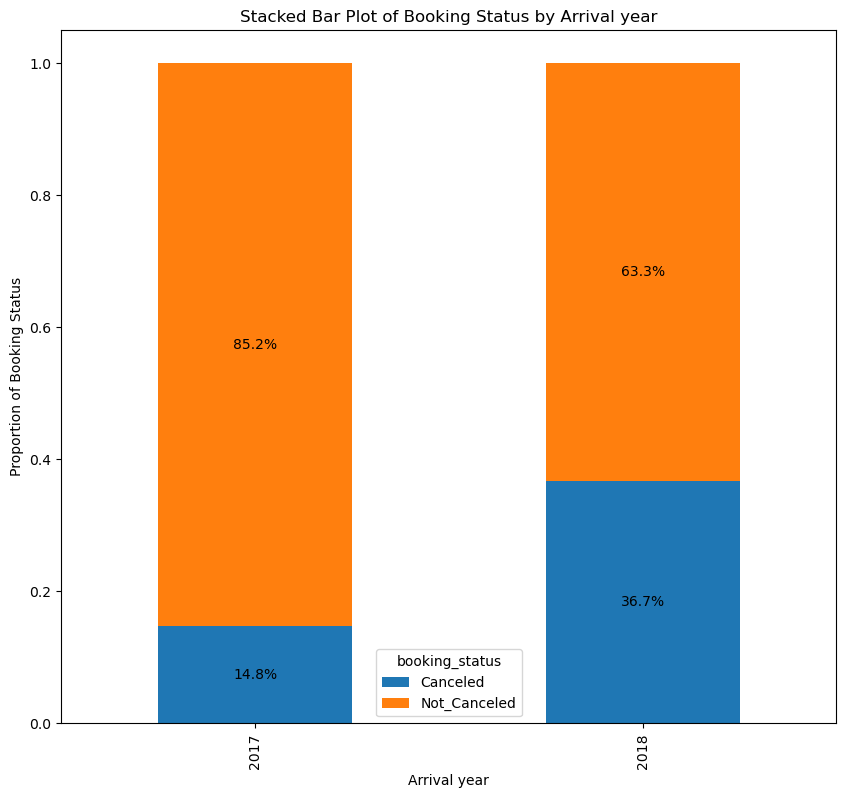

In [79]:
cross_tab_8 = pd.crosstab(df['arrival_year'], df['booking_status'], normalize='index')
ax = cross_tab_8.plot(kind='bar', stacked=True, figsize=(10, 9))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('Arrival year')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by Arrival year')
plt.show()

In [80]:
# According to the data, the number of cancellations in 2017 is lower compared to 2018.

In [81]:
df['arrival_month']=df['arrival_month'].astype('object')

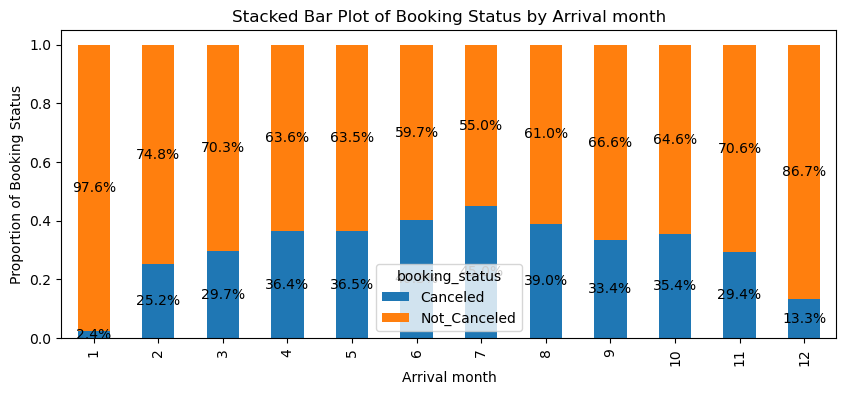

In [82]:
cross_tab_9 = pd.crosstab(df['arrival_month'], df['booking_status'], normalize='index')
ax = cross_tab_9.plot(kind='bar', stacked=True, figsize=(10, 4))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('Arrival month')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by Arrival month')
plt.show()

In [83]:
# According to the data, cancellations are generally lower in December and January, while the cancellations are higher in the middle of the year.

In [84]:
df['arrival_date']=df['arrival_date'].astype('object')

In [85]:
df['market_segment_type']=df['market_segment_type'].astype('object')

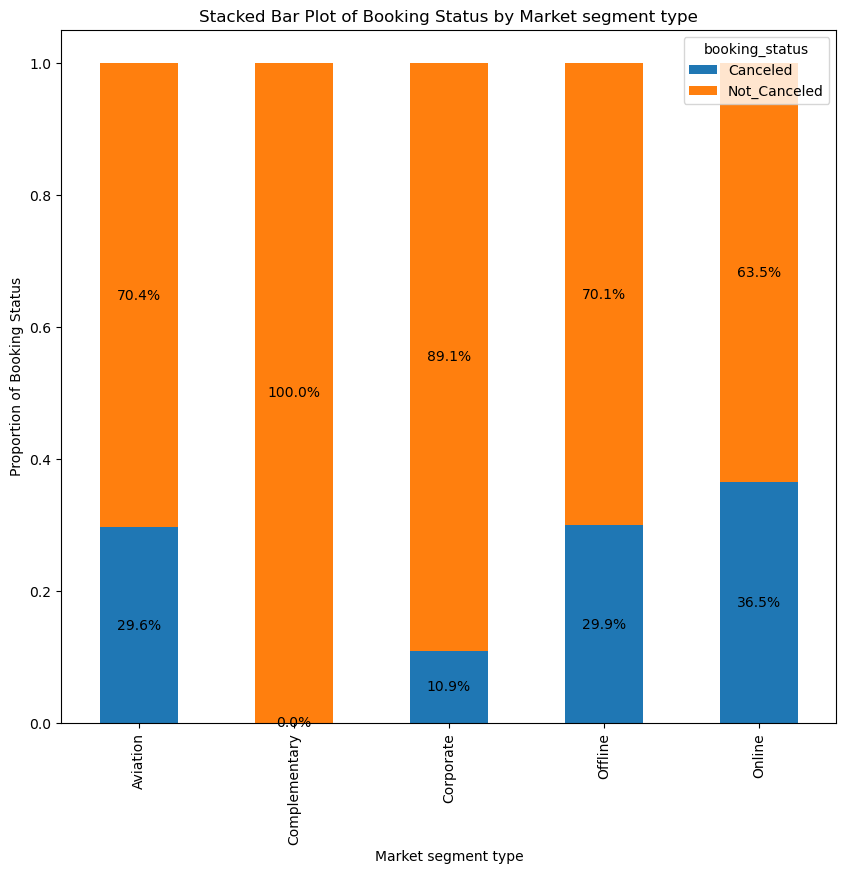

In [86]:
cross_tab_10 = pd.crosstab(df['market_segment_type'], df['booking_status'], normalize='index')
ax = cross_tab_10.plot(kind='bar', stacked=True, figsize=(10, 9))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('Market segment type')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by Market segment type')
plt.show()

In [87]:
# According to the data, cancellations are very low for complementary and corporate bookings.

In [88]:
df['repeated_guest']=df['repeated_guest'].astype('object')

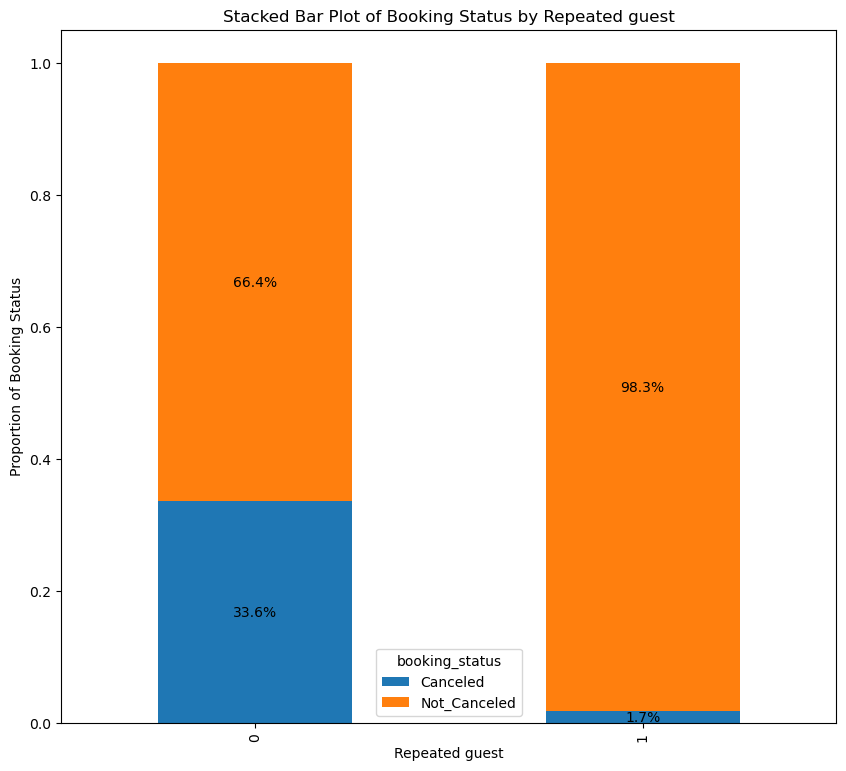

In [89]:
cross_tab_11 = pd.crosstab(df['repeated_guest'], df['booking_status'], normalize='index')
ax = cross_tab_11.plot(kind='bar', stacked=True, figsize=(10, 9))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('Repeated guest')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by Repeated guest')
plt.show()

In [90]:
#According to the data, individuals who make repeat bookings are less likely to cancel.

In [91]:
df['no_of_special_requests']=df['no_of_special_requests'].astype('object')

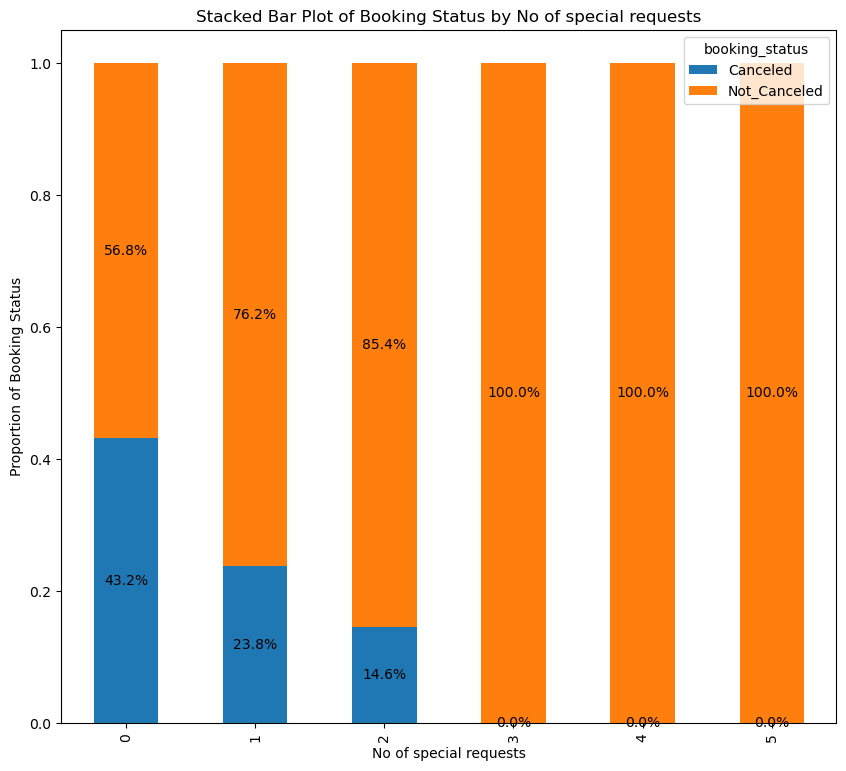

In [92]:
cross_tab_13 = pd.crosstab(df['no_of_special_requests'], df['booking_status'], normalize='index')
ax = cross_tab_13.plot(kind='bar', stacked=True, figsize=(10, 9))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('No of special requests')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by No of special requests')
plt.show()

In [93]:
# According to the data, people who make more than two special requests are less likely to cancel their hotel bookings.

In [94]:
df['no_of_previous_cancellations']=df['no_of_previous_cancellations'].astype('object')

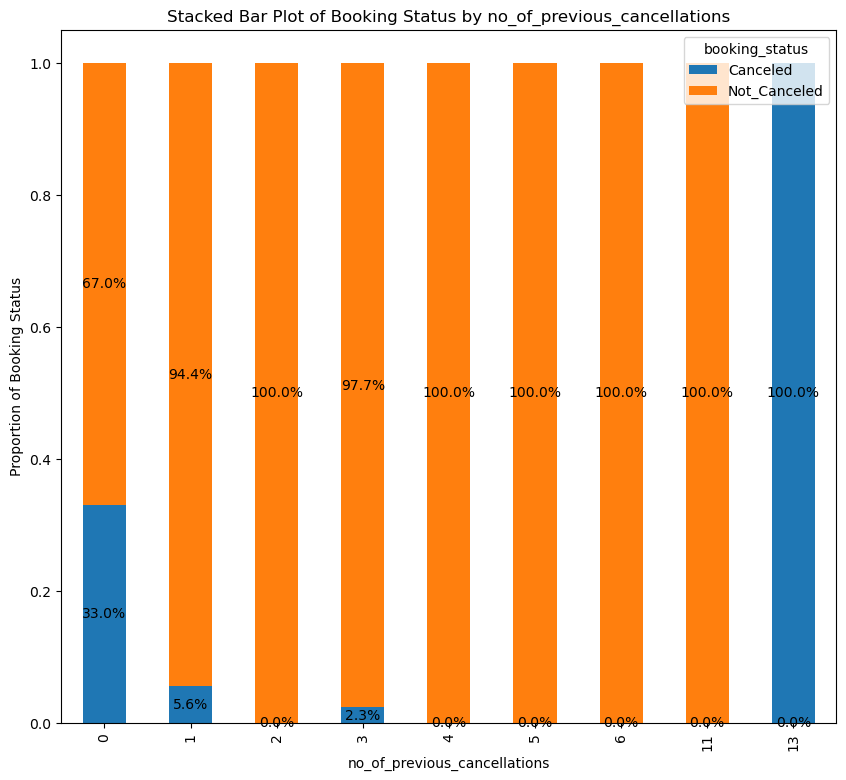

In [95]:
cross_tab_14 = pd.crosstab(df['no_of_previous_cancellations'], df['booking_status'], normalize='index')
ax = cross_tab_14.plot(kind='bar', stacked=True, figsize=(10, 9))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('no_of_previous_cancellations')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by no_of_previous_cancellations')
plt.show()

In [96]:
# According to the data, customers who had previously canceled a small number of bookings are less likely to cancel their current booking.

In [97]:
df['no_of_previous_bookings_not_canceled']=df['no_of_previous_bookings_not_canceled'].astype('object')

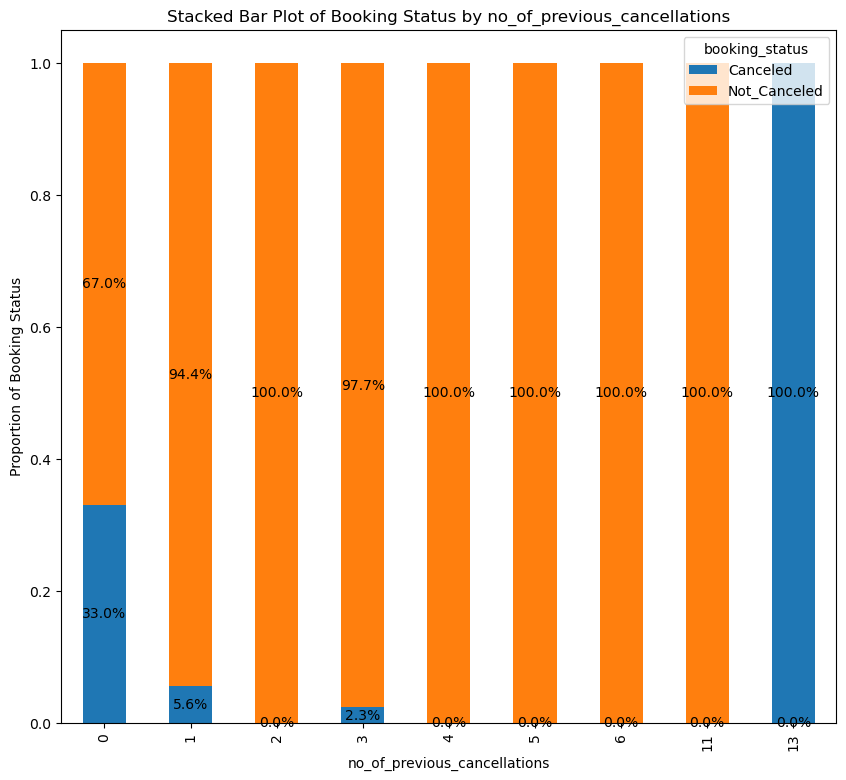

In [98]:
cross_tab_15 = pd.crosstab(df['no_of_previous_cancellations'], df['booking_status'], normalize='index')
ax = cross_tab_15.plot(kind='bar', stacked=True, figsize=(10, 9))
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            f'{height:.1%}',  
            ha='center', 
            va='center')
plt.xlabel('no_of_previous_cancellations')
plt.ylabel('Proportion of Booking Status')
plt.title('Stacked Bar Plot of Booking Status by no_of_previous_cancellations')
plt.show()

In [99]:
#  According to the data, customers who had previously not canceled are less likely to cancel their current booking.

In [100]:
df.dtypes

Booking_ID                               object
no_of_adults                             object
no_of_children                           object
no_of_weekend_nights                     object
no_of_week_nights                        object
type_of_meal_plan                        object
required_car_parking_space               object
room_type_reserved                       object
lead_time                                 int64
arrival_year                             object
arrival_month                            object
arrival_date                             object
market_segment_type                      object
repeated_guest                           object
no_of_previous_cancellations             object
no_of_previous_bookings_not_canceled     object
avg_price_per_room                      float64
no_of_special_requests                   object
booking_status                           object
dtype: object

In [101]:
categorical_features_new = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features_new = df.select_dtypes(include=np.number).columns.tolist()

In [102]:
num = df.select_dtypes(include=np.number).columns
cat = 'booking_status'

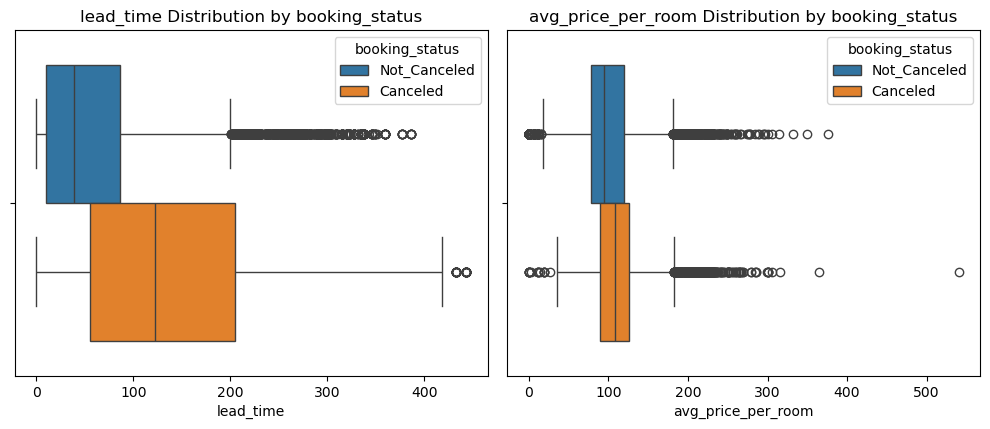

In [103]:
plt.figure(figsize=(10, 8)) 
plot_number = 1
for num_feature in num:
    plt.subplot(len(num), 2, plot_number)  
    sns.boxplot(data=df, x=num_feature, hue=cat, fill=True)  
    plt.title(f'{num_feature} Distribution by {cat}')  
    plot_number += 1
plt.tight_layout()  
plt.show()

In [104]:
# Lead Time
# According to the data, the median lead time varies significantly. Both canceled and non-canceled bookings show right skewness. 
# Additionally, non-canceled bookings have more outliers compared to canceled ones.
# Avgerage price per room
# There is no significant difference in the median average price per room between canceled and non-canceled bookings. Both categories exhibit outliers.

### Uni-Variate Analysis

In [106]:
df.select_dtypes(include='object').describe()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,no_of_special_requests,booking_status
count,36275,36275,36275,36275,36275,36275,36275,36275,36275,36275,36275,36275,36275,36275,36275,36275,36275
unique,36275,5,6,8,18,4,2,7,2,12,31,5,2,9,59,6,2
top,INN00001,2,0,0,2,Meal Plan 1,0,Room_Type 1,2018,10,13,Online,0,0,0,0,Not_Canceled
freq,1,26108,33577,16872,11444,27835,35151,28130,29761,5317,1358,23214,35345,35937,35463,19777,24390


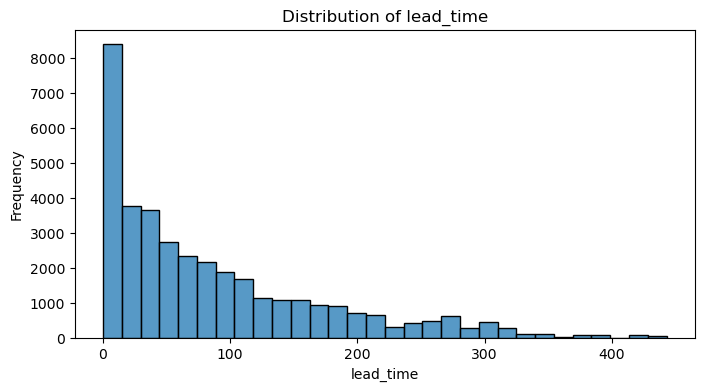

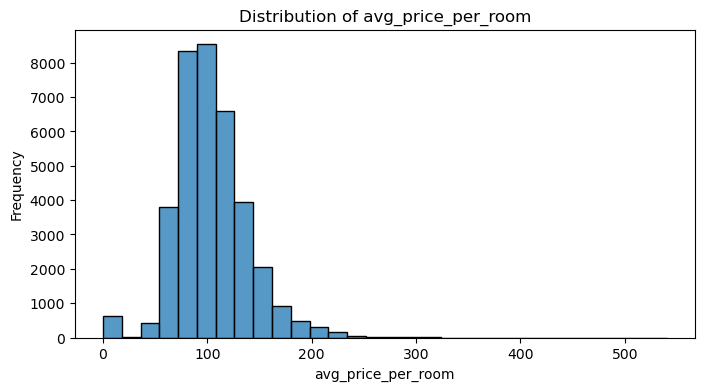

In [143]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()


In [108]:
df=df.drop(columns=['Booking_ID'])

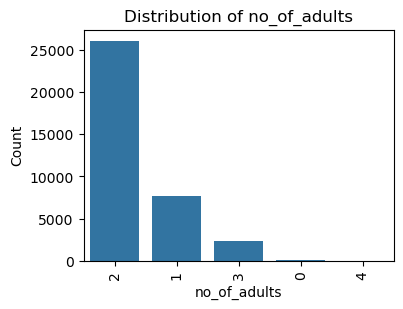

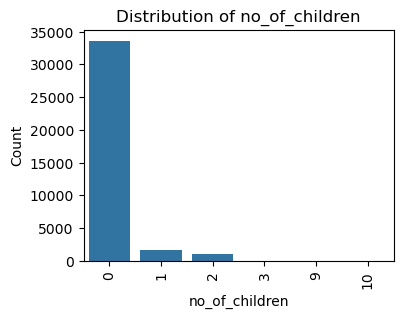

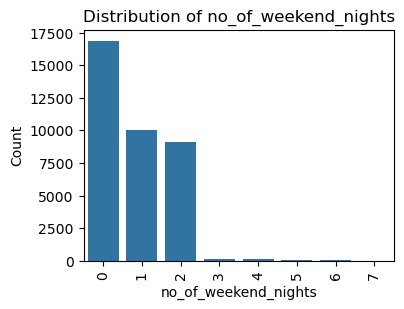

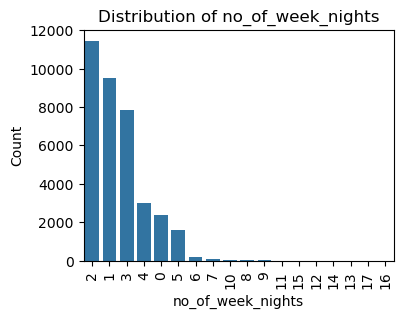

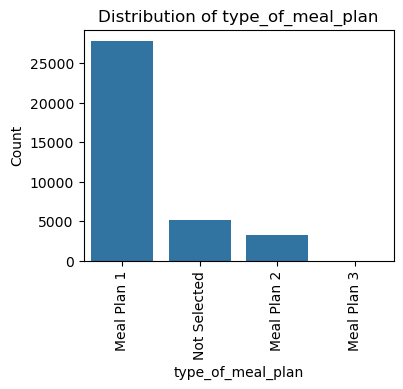

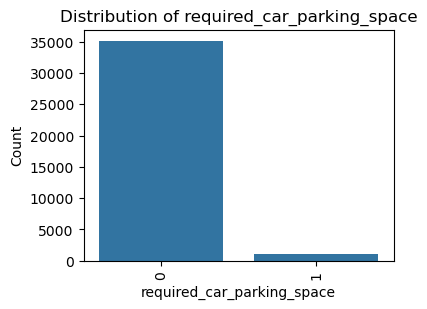

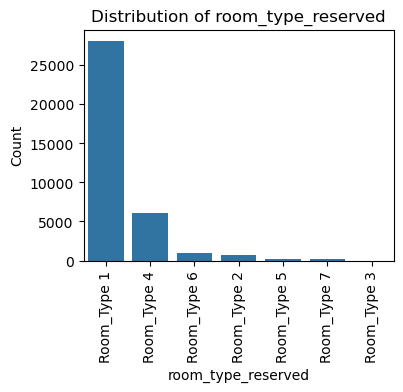

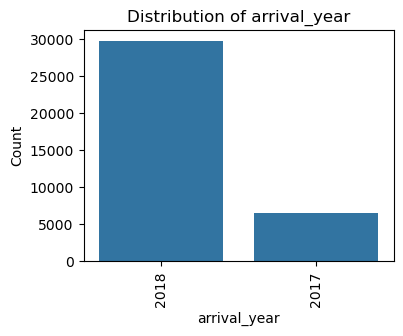

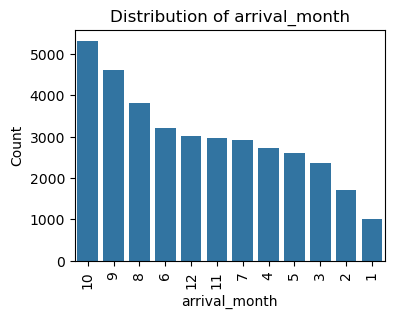

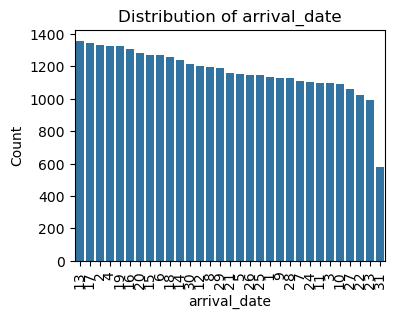

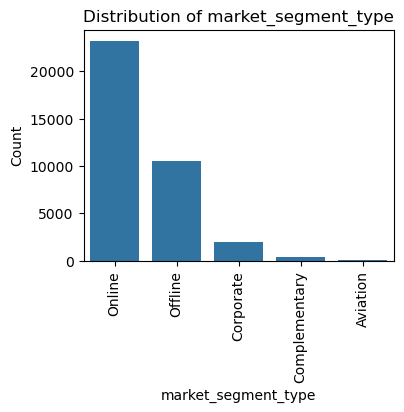

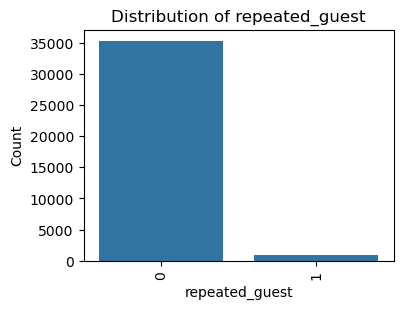

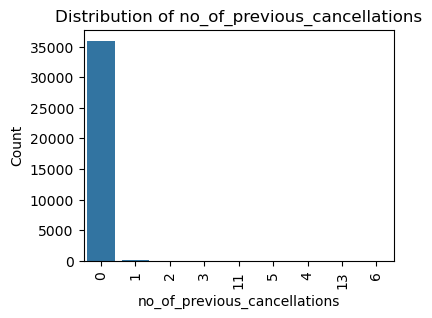

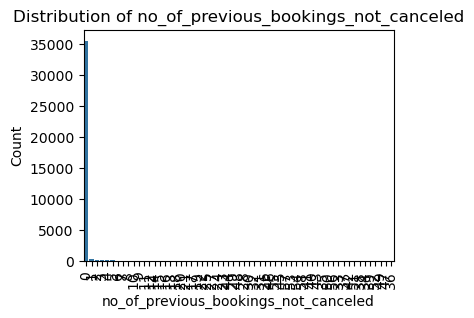

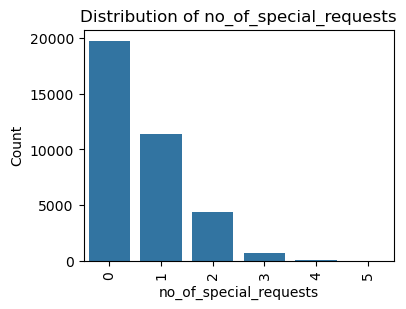

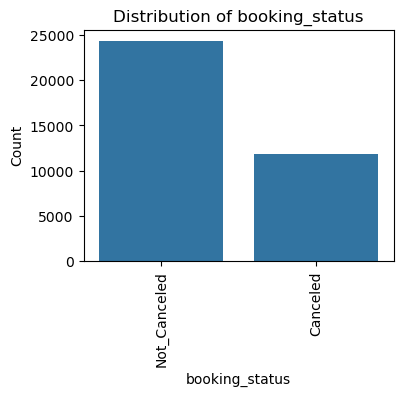

In [147]:
for feature in categorical_features:
    plt.figure(figsize=(4, 3))
    sns.countplot(x=df[feature], order=df[feature].value_counts().index)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()

In [148]:
#sns.countplot(df['booking_status'])

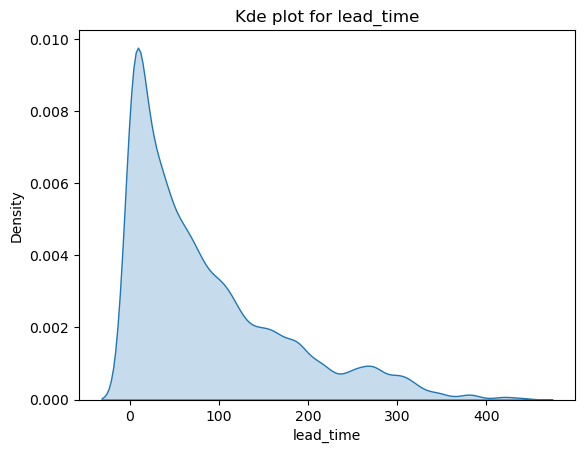

Feature: lead_time
Mean: 85.23255685733976
Median: 57.0
Mode: 0
Min: 0
Max: 443
Range: 443
variance: 7384.1052585967045
std: 85.93081669923022
skew: 1.2924915330710838
kurtosis: 1.1795940897790458
------------------------------


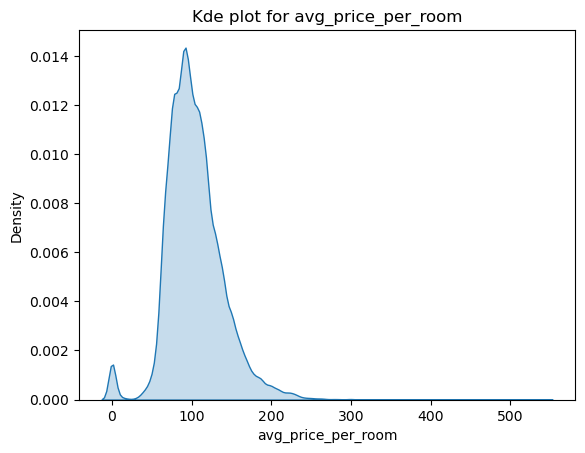

Feature: avg_price_per_room
Mean: 103.42353907649897
Median: 99.45
Mode: 65.0
Min: 0.0
Max: 540.0
Range: 540.0
variance: 1231.2676792041743
std: 35.08942403636991
skew: 0.6671328746979995
kurtosis: 3.1541250004418795
------------------------------


In [149]:
for i in numerical_features_new:
    data_columns=df[i]
    mean_val = data_columns.mean()
    median_val = data_columns.median()
    mode_val = data_columns.mode()[0]
    min_val = data_columns.min()
    max_val = data_columns.max()
    range_val = max_val - min_val
    variance=data_columns.var()
    std=data_columns.std()
    skew=data_columns.skew()
    kurt=data_columns.kurt()
    plt.figure()
    sns.kdeplot(data_columns,shade=True)
    plt.title(f"Kde plot for {i}")
    plt.show()
    
    print(f"Feature: {data_columns.name}")
    print(f"Mean: {mean_val}")
    print(f"Median: {median_val}")
    print(f"Mode: {mode_val}")
    print(f"Min: {min_val}")
    print(f"Max: {max_val}")
    print(f"Range: {range_val}")
    print(f"variance: {variance}")
    print(f"std: {std}")
    print(f"skew: {skew}")
    print(f"kurtosis: {kurt}")
    print("-" * 30)

In [150]:
# Lead time is right skewed
# avg_price_price is little right skewed

In [151]:
z_scores = np.abs(zscore(df.select_dtypes(include=[np.number])))
outliers_z = (z_scores > 3).sum(axis=0) | (z_scores < -3).sum(axis=0)
print("Outliers detected using Z-Score method:")
print(outliers_z)

Outliers detected using Z-Score method:
lead_time             376
avg_price_per_room    357
dtype: int64


In [152]:
def find_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    is_outlier = (data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))
    return is_outlier.sum()
outliers_iqr = df.select_dtypes(include=[np.number]).apply(find_outliers_iqr)
print("\nOutliers detected using IQR method:")
print(outliers_iqr)


Outliers detected using IQR method:
lead_time             1331
avg_price_per_room    1696
dtype: int64


In [153]:
df.select_dtypes(include=np.number).corr()

,lead_time,avg_price_per_room
lead_time,1.000000,-0.062596
avg_price_per_room,-0.062596,1.000000


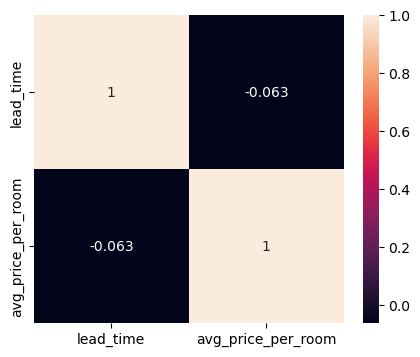

In [154]:
plt.figure(figsize=(5,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)
plt.show()

In [155]:
# The correlation matrix represents the weak negative relationship between two variables.

In [156]:
X=df[['lead_time','avg_price_per_room']]

In [157]:
vif_df=pd.DataFrame()
vif_df['vif']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif_df['Attributes']=X.columns
vif_df.sort_values(by='vif',ascending=False)

,vif,Attributes
0,1.741841,lead_time
1,1.741841,avg_price_per_room


### Statistical Test for categorical variables

In [159]:
list=[]
for i in df.select_dtypes(exclude=np.number):
    a=pd.crosstab(df[i],df['booking_status'])
    print(i,':',stats.chi2_contingency(a)[1])

no_of_adults : 3.831907699242197e-72
no_of_children : 9.996981480354703e-11
no_of_weekend_nights : 8.652980406069885e-44
no_of_week_nights : 1.0986460902695565e-81
type_of_meal_plan : 4.951915406087789e-60
required_car_parking_space : 2.547649021543868e-60
room_type_reserved : 1.5627796772447482e-10
arrival_year : 5.0468625785307046e-256
arrival_month : 2.3069606491549355e-296
arrival_date : 1.3915931305634322e-50
market_segment_type : 6.748763024557236e-175
repeated_guest : 1.7270504808167525e-92
no_of_previous_cancellations : 3.3464027245396504e-26
no_of_previous_bookings_not_canceled : 1.171444543817532e-49
no_of_special_requests : 0.0
booking_status : 0.0


In [160]:
# P-val < 0.05
# All the variables are significant

### Statistical test for Numerical variables

In [162]:
for column in df.select_dtypes(include=np.number).columns:
    stat, p_value = stats.shapiro(df[column])
    print(f"{column}: P-value = {p_value}")
    alpha = 0.05
    if p_value < alpha:
        print(f"  Reject the null hypothesis: The data in '{column}' does not follow a normal distribution.")
    else:
        print(f"  Fail to reject the null hypothesis: The data in '{column}' may follow a normal distribution.")

lead_time: P-value = 1.3140390969441834e-98
  Reject the null hypothesis: The data in 'lead_time' does not follow a normal distribution.
avg_price_per_room: P-value = 1.815858130687643e-73
  Reject the null hypothesis: The data in 'avg_price_per_room' does not follow a normal distribution.


In [163]:
# All data is not normal

In [164]:
for column in df.select_dtypes(include=np.number).columns:
    group1 = df[df['booking_status'] == 'Canceled'][column]
    group2 = df[df['booking_status'] == 'Not_Canceled'][column]
    stat, p_value = levene(group1, group2)
    print(f"{column}: Levene's Test  P-value = {p_value}")
    alpha = 0.05
    if p_value < alpha:
        print(f"{column},(p < {alpha}).")
    else:
        print(f" {column} , (p >= {alpha}).")

lead_time: Levene's Test  P-value = 0.0
lead_time,(p < 0.05).
avg_price_per_room: Levene's Test  P-value = 4.850459458307533e-27
avg_price_per_room,(p < 0.05).


In [165]:
# All variance are not equal

In [166]:
statistic, p_value = mannwhitneyu(df['lead_time'],df['avg_price_per_room'])
print(f"U-statistic: {statistic}")
print(f"P-value: {p_value}")
alpha = 0.05  
if p_value < alpha:
    print("Reject the null hypothesis: Significant difference between the groups.")
else:
    print("Fail to reject the null hypothesis: No significant difference between the groups.")

U-statistic: 442228427.5
P-value: 0.0
Reject the null hypothesis: Significant difference between the groups.


In [167]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [168]:
#df=df.drop(columns=['Booking_ID'])

In [169]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [170]:
df=pd.get_dummies(df,columns=['type_of_meal_plan','room_type_reserved','market_segment_type'])

In [171]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status',
       'type_of_meal_plan_Meal Plan 1', 'type_of_meal_plan_Meal Plan 2',
       'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected',
       'room_type_reserved_Room_Type 1', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Aviation',
       'market_segment_type_Complementary', 'market_segment_type_Corporate',
       'market_segment_type_Offline', 'market_segment_type_Online'],
      dtype='object')

In [172]:
df[['type_of_meal_plan_Meal Plan 1', 'type_of_meal_plan_Meal Plan 2','type_of_meal_plan_Meal Plan 3',
'type_of_meal_plan_Not Selected','room_type_reserved_Room_Type 1', 
'room_type_reserved_Room_Type 2','room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Aviation',
       'market_segment_type_Complementary', 'market_segment_type_Corporate',
       'market_segment_type_Offline', 'market_segment_type_Online']] = df[['type_of_meal_plan_Meal Plan 1', 'type_of_meal_plan_Meal Plan 2',
       'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected',
       'room_type_reserved_Room_Type 1', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Aviation',
       'market_segment_type_Complementary', 'market_segment_type_Corporate',
       'market_segment_type_Offline', 'market_segment_type_Online']].astype(int)

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  object 
 1   no_of_children                        36275 non-null  object 
 2   no_of_weekend_nights                  36275 non-null  object 
 3   no_of_week_nights                     36275 non-null  object 
 4   required_car_parking_space            36275 non-null  object 
 5   lead_time                             36275 non-null  int64  
 6   arrival_year                          36275 non-null  object 
 7   arrival_month                         36275 non-null  object 
 8   arrival_date                          36275 non-null  object 
 9   repeated_guest                        36275 non-null  object 
 10  no_of_previous_cancellations          36275 non-null  object 
 11  no_of_previous_

In [174]:
df['no_of_special_requests'].value_counts()

no_of_special_requests
0    19777
1    11373
2     4364
3      675
4       78
5        8
Name: count, dtype: int64

In [175]:
df.dtypes

no_of_adults                             object
no_of_children                           object
no_of_weekend_nights                     object
no_of_week_nights                        object
required_car_parking_space               object
lead_time                                 int64
arrival_year                             object
arrival_month                            object
arrival_date                             object
repeated_guest                           object
no_of_previous_cancellations             object
no_of_previous_bookings_not_canceled     object
avg_price_per_room                      float64
no_of_special_requests                   object
booking_status                           object
type_of_meal_plan_Meal Plan 1             int32
type_of_meal_plan_Meal Plan 2             int32
type_of_meal_plan_Meal Plan 3             int32
type_of_meal_plan_Not Selected            int32
room_type_reserved_Room_Type 1            int32
room_type_reserved_Room_Type 2          

In [176]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status',
       'type_of_meal_plan_Meal Plan 1', 'type_of_meal_plan_Meal Plan 2',
       'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected',
       'room_type_reserved_Room_Type 1', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Aviation',
       'market_segment_type_Complementary', 'market_segment_type_Corporate',
       'market_segment_type_Offline', 'market_segment_type_Online'],
      dtype='object')

### Encoding

In [178]:
df['booking_status']=df['booking_status'].map({'Not_Canceled':0,'Canceled':1})

In [179]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,2017,10,2,0,...,0,0,0,0,0,0,0,0,1,0
1,2,0,2,3,0,5,2018,11,6,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,2,1,0,1,2018,2,28,0,...,0,0,0,0,0,0,0,0,0,1
3,2,0,0,2,0,211,2018,5,20,0,...,0,0,0,0,0,0,0,0,0,1
4,2,0,1,1,0,48,2018,4,11,0,...,0,0,0,0,0,0,0,0,0,1


In [180]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status',
       'type_of_meal_plan_Meal Plan 1', 'type_of_meal_plan_Meal Plan 2',
       'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected',
       'room_type_reserved_Room_Type 1', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Aviation',
       'market_segment_type_Complementary', 'market_segment_type_Corporate',
       'market_segment_type_Offline', 'market_segment_type_Online'],
      dtype='object')

### Scaling

In [182]:
rs=RobustScaler()

In [183]:
data_scaled_rs = rs.fit_transform(df[['lead_time', 'avg_price_per_room']]) 

In [184]:
df[['lead_time', 'avg_price_per_room']].describe()

,lead_time,avg_price_per_room
count,36275.000000,36275.000000
mean,85.232557,103.423539
std,85.930817,35.089424
min,0.000000,0.000000
25%,17.000000,80.300000
50%,57.000000,99.450000
75%,126.000000,120.000000
max,443.000000,540.000000


In [185]:
scaled_df = pd.DataFrame(data_scaled_rs, columns=['lead_time_rs', 'avg_price_per_room_rs'])

In [186]:
df_scaled=pd.concat([df,scaled_df],axis=1)

In [187]:
df_scaled.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,lead_time_rs,avg_price_per_room_rs
0,2,0,1,2,0,224,2017,10,2,0,...,0,0,0,0,0,0,1,0,1.532110,-0.867758
1,2,0,2,3,0,5,2018,11,6,0,...,0,0,0,0,0,0,0,1,-0.477064,0.182116
2,1,0,2,1,0,1,2018,2,28,0,...,0,0,0,0,0,0,0,1,-0.513761,-0.993703
3,2,0,0,2,0,211,2018,5,20,0,...,0,0,0,0,0,0,0,1,1.412844,0.013854
4,2,0,1,1,0,48,2018,4,11,0,...,0,0,0,0,0,0,0,1,-0.082569,-0.124685


### Data Imbalance

In [189]:
df_scaled['booking_status'].value_counts()/df_scaled['booking_status'].value_counts().sum() *100

booking_status
0    67.236389
1    32.763611
Name: count, dtype: float64

In [190]:
df_scaled.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status',
       'type_of_meal_plan_Meal Plan 1', 'type_of_meal_plan_Meal Plan 2',
       'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected',
       'room_type_reserved_Room_Type 1', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Aviation',
       'market_segment_type_Complementary', 'market_segment_type_Corporate',
       'market_segment_type_Offline', 'market_segment_type_Online',
       'lead_time_rs', 'avg_price_per_room_rs'],

### Base Model (Logistic Regression)

In [192]:
X,y=df_scaled.drop(columns=['booking_status']),df_scaled['booking_status']

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [194]:
lr=LogisticRegression()
model=lr.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [195]:
def get_train_report(model):
    train_pred = model.predict(X_train)
    return(classification_report(y_train, train_pred))

In [196]:
def get_test_report(model):
    test_pred = model.predict(X_test)
    return(classification_report(y_test, test_pred))

In [197]:
train_report = get_train_report(model)
print(train_report)

              precision    recall  f1-score   support

           0       0.82      0.90      0.86     19547
           1       0.74      0.60      0.66      9473

    accuracy                           0.80     29020
   macro avg       0.78      0.75      0.76     29020
weighted avg       0.79      0.80      0.79     29020



In [198]:
test_report = get_test_report(model)
print(test_report)

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      4843
           1       0.74      0.60      0.67      2412

    accuracy                           0.80      7255
   macro avg       0.78      0.75      0.76      7255
weighted avg       0.79      0.80      0.79      7255



In [199]:
conf_matrix = confusion_matrix(y_test, y_pred)

In [200]:
print(conf_matrix)

[[4341  502]
 [ 957 1455]]


In [212]:
def plot_confusion_matrix(model):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
    sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = ListedColormap(['lightskyblue']), cbar = False, 
                linewidths = 0.1, annot_kws = {'size':25})
    plt.xticks(fontsize = 20)
    plt.yticks(fontsize = 20)
    plt.show()

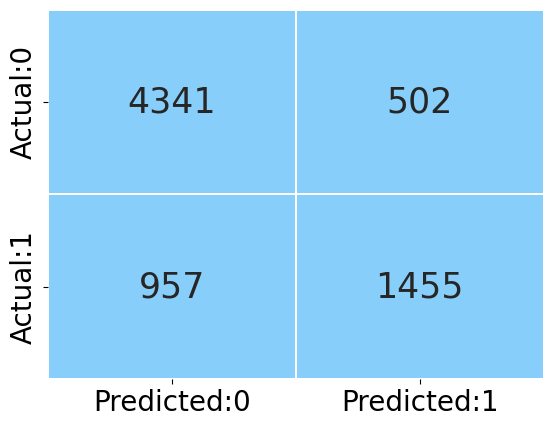

In [216]:
plot_confusion_matrix(model)

In [218]:
# class 1 indicates the booking_status cancelled
# class 0 indicated the booking_status not-cancelled

In [219]:
# Recall class[1] - This tells that how many actual cancellations are being correctly predicted,
#                   Here recall is 0.60 meaning that model catches 60 % of all cancellations.
# Precision class[1] - out of all instances predicted as 'CANCEL',74 % were actually cancelled.
# F1-score class[1] - Mean of precision and recall, moderate balance between the two cancellation.
# Recall class[0] - This tells that how many actual bookings are being correctly predicted,
#                   Here recall is 0.89, model catches 89 % of all bookings.
# Precision class[0] - Out of all the instances predicted as 'Not cancelled', 82 % were actually not cancelled the bookings.
# F1-score class[0] - Mean of precision and recall, indicating strong performance in predicting ' Not-cancelled'.

In [220]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

In [221]:
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)


In [222]:
youden_index = sensitivity + specificity - 1

print(f"Sensitivity: {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"Youden's Index: {youden_index:.2f}")

Sensitivity: 0.60
Specificity: 0.90
Youden's Index: 0.50


#### Decision Tree

In [224]:
def get_train_report(model):
    train_pred = model.predict(X_train)
    return(classification_report(y_train, train_pred))

In [225]:
def get_test_report(model):
    test_pred = model.predict(X_test)
    return(classification_report(y_test, test_pred))

In [226]:
tuned_paramaters = [{'criterion': ['entropy', 'gini'],
        'max_depth': range(2, 20),
        'min_samples_split': range(2, 10),
        'min_samples_leaf': range(1, 5),
        'class_weight': ['balanced', None]}]
decision_tree_classification = DecisionTreeClassifier(random_state = 10)
tree_grid = GridSearchCV(estimator = decision_tree_classification,
                         param_grid = tuned_paramaters,
                         cv = 5,
                         n_jobs=-1)
tree_grid_model = tree_grid.fit(X_train, y_train)
print('Best parameters for decision tree classifier: ', tree_grid_model.best_params_, '\n')

In [227]:
decision_tree_classification = DecisionTreeClassifier(criterion = 'gini',max_depth = 16,
                                  min_samples_split = 2, min_samples_leaf = 2, class_weight = None,
                                  random_state = 42)
decision_tree = decision_tree_classification.fit(X_train, y_train)

In [228]:
train_report = get_train_report(decision_tree)
print(train_report)

              precision    recall  f1-score   support

           0       0.94      0.95      0.94     19547
           1       0.90      0.86      0.88      9473

    accuracy                           0.92     29020
   macro avg       0.92      0.91      0.91     29020
weighted avg       0.92      0.92      0.92     29020



In [229]:
test_report = get_test_report(decision_tree)
print(test_report)

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      4843
           1       0.82      0.80      0.81      2412

    accuracy                           0.88      7255
   macro avg       0.86      0.86      0.86      7255
weighted avg       0.88      0.88      0.88      7255



In [230]:
def plot_confusion_matrix(model):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
    sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = ListedColormap(['lightskyblue']), cbar = False, 
                linewidths = 0.1, annot_kws = {'size':25})
    plt.xticks(fontsize = 20)
    plt.yticks(fontsize = 20)
    plt.show()

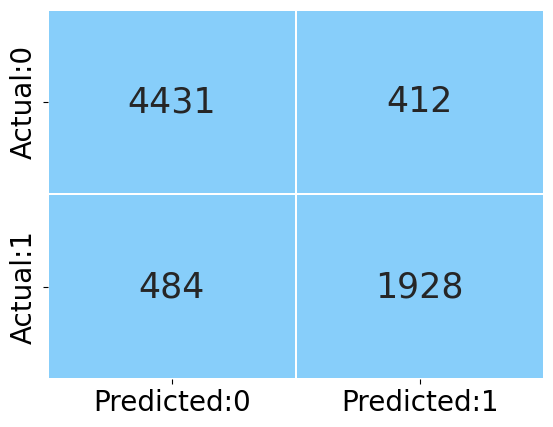

In [231]:
plot_confusion_matrix(decision_tree)

#### Random Forest

In [233]:
tuned_paramaters = [{'criterion': ['Entropy','gini'],
                     'n_estimators': range(50, 150, 20),
                     'max_depth': [10, 15, 20],
                     'min_samples_split': [ 5, 8, 11],  
                     'class_weight': ['balanced', None],
                     'max_features': ['sqrt', 'log2'] }]
random_forest_classification = RandomForestClassifier(random_state = 10)
rf_grid = GridSearchCV(estimator = random_forest_classification,
                       param_grid = tuned_paramaters,
                       cv = 15)
rf_grid_model = rf_grid.fit(X_train, y_train)
print('Best parameters for random forest classifier: ', rf_grid_model.best_params_, '\n')

In [234]:
rf_classification = RandomForestClassifier(n_estimators= 110,class_weight= None,criterion='gini',max_depth=20,min_samples_split=5,max_features='sqrt',random_state=10)
rf_model = rf_classification.fit(X_train, y_train)

In [237]:
train_report = get_train_report(rf_model)
print(train_report)

              precision    recall  f1-score   support

           0       0.95      0.98      0.96     19547
           1       0.95      0.89      0.92      9473

    accuracy                           0.95     29020
   macro avg       0.95      0.93      0.94     29020
weighted avg       0.95      0.95      0.95     29020



In [238]:
test_report = get_test_report(rf_model)
print(test_report)

              precision    recall  f1-score   support

           0       0.90      0.95      0.93      4843
           1       0.89      0.80      0.84      2412

    accuracy                           0.90      7255
   macro avg       0.90      0.87      0.88      7255
weighted avg       0.90      0.90      0.90      7255



In [239]:
def plot_confusion_matrix(model):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
    sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = ListedColormap(['lightskyblue']), cbar = False, 
                linewidths = 0.1, annot_kws = {'size':25})
    plt.xticks(fontsize = 20)
    plt.yticks(fontsize = 20)
    plt.show()

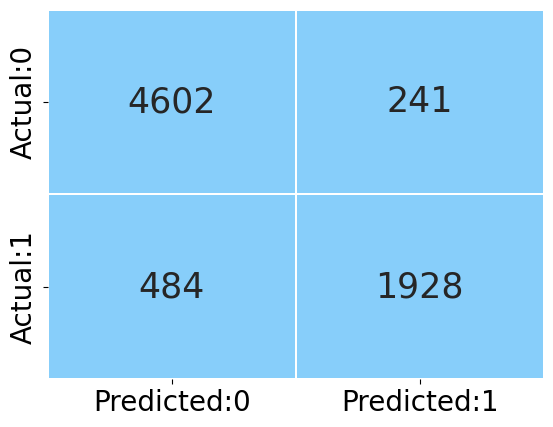

In [240]:
plot_confusion_matrix(rf_model)

#### Gradient Boosting

In [242]:
gboost_model = GradientBoostingClassifier( random_state = 10)
gboost_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=10)

In [243]:
train_report = get_train_report(gboost_model)
print(train_report)

              precision    recall  f1-score   support

           0       0.86      0.93      0.90     19547
           1       0.83      0.70      0.76      9473

    accuracy                           0.85     29020
   macro avg       0.85      0.81      0.83     29020
weighted avg       0.85      0.85      0.85     29020



In [244]:
test_report = get_test_report(gboost_model)
print(test_report)

              precision    recall  f1-score   support

           0       0.86      0.93      0.89      4843
           1       0.83      0.70      0.76      2412

    accuracy                           0.85      7255
   macro avg       0.84      0.81      0.82      7255
weighted avg       0.85      0.85      0.85      7255



In [245]:
gbc = GradientBoostingClassifier()
param_grid = {
    'n_estimators': np.array([300]), 
    'learning_rate': np.array([0.01, 0.02, 0.05, 0.07, 0.09, 0.1, 0.3, 0.5, 0.005]) 
}
grid_search = GridSearchCV(estimator=gbc, param_grid=param_grid, cv=10, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print("Best hyperparameters:", best_params)

In [246]:
gboost_model = GradientBoostingClassifier(learning_rate=0.3,n_estimators=300, random_state = 10)
gboost_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.3, n_estimators=300, random_state=10)

In [247]:
train_report = get_train_report(gboost_model)
print(train_report)

              precision    recall  f1-score   support

           0       0.91      0.95      0.93     19547
           1       0.88      0.81      0.84      9473

    accuracy                           0.90     29020
   macro avg       0.90      0.88      0.89     29020
weighted avg       0.90      0.90      0.90     29020



In [248]:
test_report = get_test_report(gboost_model)
print(test_report)

              precision    recall  f1-score   support

           0       0.90      0.93      0.91      4843
           1       0.86      0.78      0.82      2412

    accuracy                           0.88      7255
   macro avg       0.88      0.86      0.87      7255
weighted avg       0.88      0.88      0.88      7255



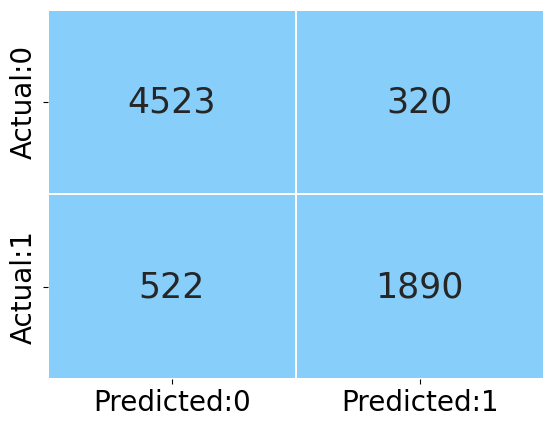

In [249]:
plot_confusion_matrix(gboost_model)

### XG BOOST

In [331]:
X_train['no_of_adults'] = pd.to_numeric(X_train['no_of_adults'], errors='coerce')
X_train['no_of_children'] = pd.to_numeric(X_train['no_of_children'], errors='coerce')
X_train['no_of_weekend_nights'] = pd.to_numeric(X_train['no_of_weekend_nights'], errors='coerce')
X_train['no_of_week_nights'] = pd.to_numeric(X_train['no_of_week_nights'], errors='coerce')
X_train['arrival_month'] = X_train['arrival_month'].astype(int)
X_train['repeated_guest'] = X_train['repeated_guest'].astype(int)

In [333]:
X_train['required_car_parking_space'] = X_train['required_car_parking_space'].astype(int)
X_train['arrival_year'] = X_train['arrival_year'].astype(int)
X_train['arrival_date'] = X_train['arrival_date'].astype(int)
X_train['no_of_previous_cancellations'] = X_train['no_of_previous_cancellations'].astype(int)
X_train['no_of_previous_bookings_not_canceled'] = X_train['no_of_previous_bookings_not_canceled'].astype(int)
X_train['no_of_special_requests'] = X_train['no_of_special_requests'].astype(int)

In [347]:
X_test['no_of_adults'] = pd.to_numeric(X_test['no_of_adults'], errors='coerce')
X_test['no_of_children'] = pd.to_numeric(X_test['no_of_children'], errors='coerce')
X_test['no_of_weekend_nights'] = pd.to_numeric(X_test['no_of_weekend_nights'], errors='coerce')
X_test['no_of_week_nights'] = pd.to_numeric(X_test['no_of_week_nights'], errors='coerce')
X_test['arrival_month'] = X_test['arrival_month'].astype(int)
X_test['repeated_guest'] = X_test['repeated_guest'].astype(int)

In [349]:
X_test['required_car_parking_space'] = X_test['required_car_parking_space'].astype(int)
X_test['arrival_year'] = X_test['arrival_year'].astype(int)
X_test['arrival_date'] = X_test['arrival_date'].astype(int)
X_test['no_of_previous_cancellations'] = X_test['no_of_previous_cancellations'].astype(int)
X_test['no_of_previous_bookings_not_canceled'] = X_test['no_of_previous_bookings_not_canceled'].astype(int)
X_test['no_of_special_requests'] = X_test['no_of_special_requests'].astype(int)

In [335]:
xgb_model = XGBClassifier(max_depth=6, learning_rate=0.1, n_estimators=100)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [337]:
train_report = get_train_report(xgb_model)
print(train_report)

              precision    recall  f1-score   support

           0       0.90      0.94      0.92     19547
           1       0.87      0.78      0.82      9473

    accuracy                           0.89     29020
   macro avg       0.88      0.86      0.87     29020
weighted avg       0.89      0.89      0.89     29020



In [351]:
test_report = get_test_report(xgb_model)
print(test_report)

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4843
           1       0.85      0.77      0.81      2412

    accuracy                           0.88      7255
   macro avg       0.87      0.85      0.86      7255
weighted avg       0.88      0.88      0.88      7255



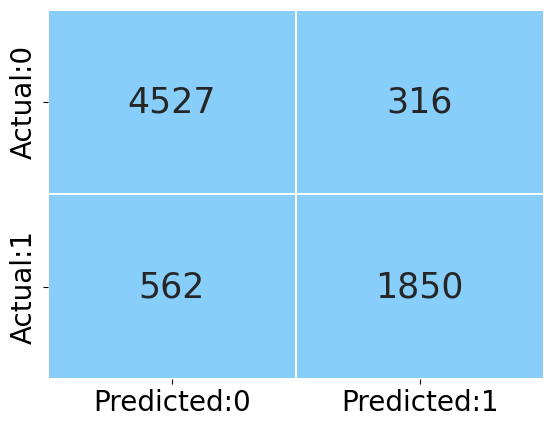

In [353]:
plot_confusion_matrix(xgb_model)

In [257]:
tuning_parameters = {'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
                     'max_depth': range(3,10),
                     'gamma': [0, 1, 2, 3, 4]}
xgb_model = XGBClassifier()
xgb_grid = GridSearchCV(estimator = xgb_model, param_grid = tuning_parameters, cv = 10, scoring = 'roc_auc')
xgb_grid.fit(X_train, y_train)
print('Best parameters for XGBoost classifier: ', xgb_grid.best_params_, '\n')

In [355]:
xgb_model = XGBClassifier(max_depth=9, learning_rate=0.3, gamma=0,n_estimators=100)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [357]:
train_report = get_train_report(xgb_model)
print(train_report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     19547
           1       0.97      0.94      0.96      9473

    accuracy                           0.97     29020
   macro avg       0.97      0.97      0.97     29020
weighted avg       0.97      0.97      0.97     29020



In [359]:
test_report = get_test_report(xgb_model)
print(test_report)

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      4843
           1       0.87      0.80      0.84      2412

    accuracy                           0.90      7255
   macro avg       0.89      0.87      0.88      7255
weighted avg       0.89      0.90      0.89      7255



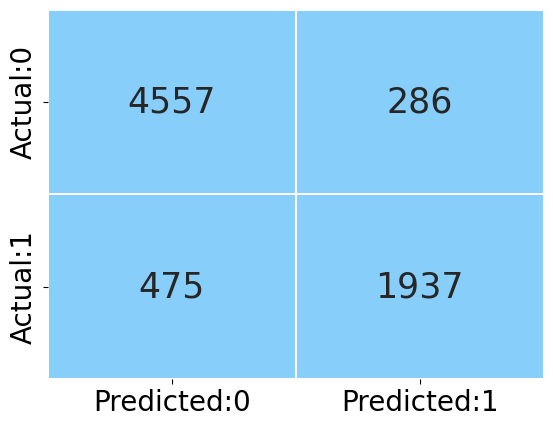

In [361]:
plot_confusion_matrix(xgb_model)

### Ada_boost

In [263]:
ada_boost = AdaBoostClassifier(n_estimators=100,random_state=42)
ada_boost.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [264]:
train_report = get_train_report(ada_boost)
print(train_report)

              precision    recall  f1-score   support

           0       0.86      0.89      0.87     19547
           1       0.75      0.69      0.72      9473

    accuracy                           0.82     29020
   macro avg       0.80      0.79      0.80     29020
weighted avg       0.82      0.82      0.82     29020



In [265]:
test_report = get_test_report(ada_boost)
print(test_report)

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      4843
           1       0.75      0.69      0.71      2412

    accuracy                           0.82      7255
   macro avg       0.80      0.78      0.79      7255
weighted avg       0.82      0.82      0.82      7255



In [266]:
ada_boost = AdaBoostClassifier(estimator=DecisionTreeClassifier())
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1.0],
    'estimator__max_depth': [1, 2, 3]
}
grid_search = GridSearchCV(estimator=ada_boost, param_grid=param_grid, 
                           cv=10, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Accuracy: {grid_search.best_score_}")

In [267]:
base_estimator = DecisionTreeClassifier(max_depth=3)
ada_boost = AdaBoostClassifier(
    estimator=base_estimator,  
    n_estimators=150,        
    learning_rate=1.0,        
    random_state=42            
)
ada_boost.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                   n_estimators=150, random_state=42)

In [268]:
train_report = get_train_report(ada_boost)
print(train_report)

              precision    recall  f1-score   support

           0       0.92      0.94      0.93     19547
           1       0.87      0.83      0.85      9473

    accuracy                           0.90     29020
   macro avg       0.89      0.88      0.89     29020
weighted avg       0.90      0.90      0.90     29020



In [269]:
test_report = get_test_report(ada_boost)
print(test_report)

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      4843
           1       0.83      0.79      0.81      2412

    accuracy                           0.88      7255
   macro avg       0.86      0.85      0.86      7255
weighted avg       0.88      0.88      0.88      7255



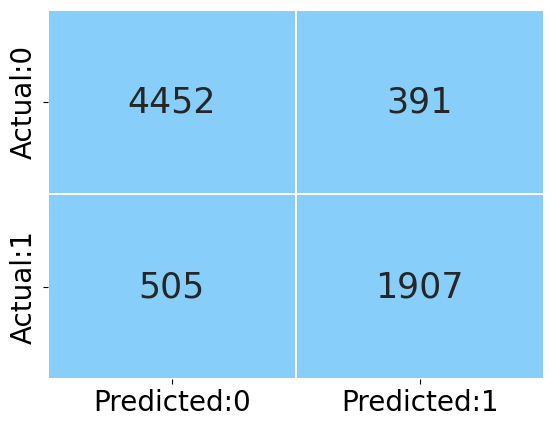

In [270]:
plot_confusion_matrix(ada_boost)